In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error

In [2]:
df = pd.read_csv("/content/insurance.csv")

In [3]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
LE = LabelEncoder()
df['sex'] = LE.fit_transform(df['sex'])
df['smoker'] = LE.fit_transform(df['smoker'])
df['region'] = LE.fit_transform(df['region'])

In [8]:
SS = StandardScaler()
df['charges'] = SS.fit_transform(df[['charges']])

In [9]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,0.298584
1,18,1,33.770,1,0,2,-0.953689
2,28,1,33.000,3,0,2,-0.728675
3,33,1,22.705,0,0,1,0.719843
4,32,1,28.880,0,0,1,-0.776802
5,31,0,25.740,0,0,2,-0.785908
6,46,0,33.440,1,0,2,-0.415500
7,37,0,27.740,3,0,1,-0.494728
8,37,1,29.830,2,0,0,-0.567017
9,60,0,25.840,0,0,1,1.293027


In [10]:
df.describe()

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1.338000e+03
mean,39.207025,0.505232,30.663397,1.094918,0.204783,1.515695,-8.098488e-17
std,14.049960,0.500160,6.098187,1.205493,0.403694,1.104885,1.000374e+00
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,-1.003557e+00
25%,27.000000,0.000000,26.296250,0.000000,0.000000,1.000000,-7.046504e-01
50%,39.000000,1.000000,30.400000,1.000000,0.000000,2.000000,-3.212089e-01
75%,51.000000,1.000000,34.693750,2.000000,0.000000,2.000000,2.783441e-01
max,64.000000,1.000000,53.130000,5.000000,1.000000,3.000000,4.171663e+00


In [11]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [12]:
X = df.drop(columns = 'charges',axis = 1)
Y = df['charges']

In [13]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2,random_state = 42)

In [14]:
model = LinearRegression()

In [15]:
model.fit(X_train,Y_train)

LinearRegression()

In [16]:
y_pred = model.predict(X_test)

In [17]:
r2 = r2_score(Y_test,y_pred)
mse = mean_squared_error(Y_test,y_pred)

In [18]:
r2

0.7833463107364538

In [19]:
mse

0.2295248768396857

In [23]:
input = [[32,1,28.880,0,0,1]]

In [24]:
new_bike_charge = model.predict(input)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [25]:
print("New predicted Bike Charge :",new_bike_charge[0])

New predicted Bike Charge : -0.626487470257107


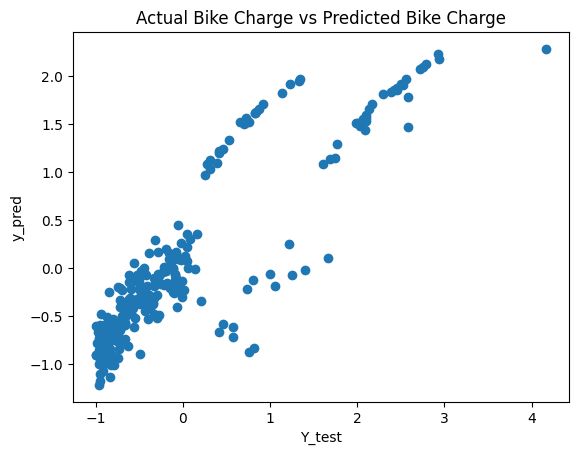

In [26]:
plt.scatter(Y_test,y_pred)
plt.xlabel("Y_test")
plt.ylabel("y_pred")
plt.title("Actual Bike Charge vs Predicted Bike Charge")
plt.show()